# Learning from callbacks

An evaluation score answers whether a policy earned reward. During Q-learning or SARSA, callbacks can answer the next questions: how long did each episode last, did it terminate or time out, which states did the agent visit, and which actions did it try? These diagnostics help explain *why* a result looks good or bad without changing the learning algorithm.

This tutorial uses deterministic FrozenLake so the saved results are reproducible. `Callbacks` and its typed contexts are the current public callback API.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bettermdptools.algorithms.planner import Planner
from bettermdptools.algorithms.rl import RL
from bettermdptools.plotting import (
    plot_learning_curve,
    plot_value_heatmap,
    prepare_learning_curve,
    prepare_value_grid,
)
from bettermdptools.utils.callbacks import (
    Callbacks,
    EnvStepContext,
    EpisodeEndContext,
)
from bettermdptools.utils.test_env import TestEnv

## 1. What does normal policy evaluation tell us?

First, solve FrozenLake with value iteration and evaluate the policy with `TestEnv.test_env(...)`. Its standard return value is one total reward per evaluation episode, which is ideal for summaries such as the mean and success rate.

In [2]:
planning_env = gym.make("FrozenLake-v1", is_slippery=False)
try:
    _, _, policy = Planner(planning_env.unwrapped.P).value_iteration()
finally:
    planning_env.close()

evaluation_env = gym.make("FrozenLake-v1", is_slippery=False)
try:
    evaluation_scores = TestEnv.test_env(evaluation_env, n_iters=10, pi=policy, seed=17)
finally:
    evaluation_env.close()

print("episode returns:", evaluation_scores)
print(f"mean return: {evaluation_scores.mean():.2f}")

episode returns: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
mean return: 1.00


Every evaluation episode succeeds, so this policy is reliable on this deterministic map. The reward array does not say how many steps each episode took or what happened inside it. Callbacks provide that context during model-free training.

## 2. Are training episodes becoming more successful and efficient?

An episode-level callback records the completed episode's return, length, and ending. It keeps diagnostics local to this training run and receives values already calculated by the algorithm.

In [3]:
class EpisodeDiagnostics(Callbacks):
    def __init__(self):
        self.records = []

    def on_episode_end(self, context: EpisodeEndContext) -> None:
        self.records.append(
            {
                "episode": context.episode,
                "return": context.total_reward,
                "length": context.step_count,
                "outcome": ("success" if context.total_reward > 0 else "failure"),
                "terminated": context.terminated,
                "truncated": context.truncated,
            }
        )


episode_diagnostics = EpisodeDiagnostics()
training_env = gym.make("FrozenLake-v1", is_slippery=False)
try:
    RL(training_env, callbacks=episode_diagnostics).q_learning(n_episodes=1500, seed=7)
finally:
    training_env.close()

episodes = pd.DataFrame(episode_diagnostics.records)
episodes["block"] = episodes["episode"] // 250 + 1
episode_summary = episodes.groupby("block").agg(
    success_rate=("return", "mean"),
    mean_length=("length", "mean"),
    truncations=("truncated", "sum"),
)
episode_summary.round(3)

,success_rate,mean_length,truncations
block,,,
1,0.148,7.888,0
2,0.576,6.724,0
3,0.760,6.564,0
4,0.808,6.284,0
5,0.888,6.464,0
6,0.912,6.300,0


Success becomes much more common across the six 250-episode blocks. Mean episode length is useful alongside return: it distinguishes a quick failure from a longer attempt, while the zero truncation count confirms that the time limit is not ending these runs.

## 3. Which states and actions does training actually cover?

The normal training and evaluation results do not include state visitation or action counts. `on_env_step` sees each converted transition before its TD update, so it can collect both without modifying Q-learning.

In [4]:
class TransitionDiagnostics(Callbacks):
    def __init__(self, n_states: int, n_actions: int):
        self.state_visits = np.zeros(n_states, dtype=int)
        self.action_counts = np.zeros(n_actions, dtype=int)

    def on_env_step(self, context: EnvStepContext) -> None:
        self.state_visits[context.state] += 1
        self.action_counts[context.action] += 1
        if context.terminated or context.truncated:
            self.state_visits[context.next_state] += 1


transition_diagnostics = TransitionDiagnostics(n_states=16, n_actions=4)
coverage_env = gym.make("FrozenLake-v1", is_slippery=False)
try:
    RL(coverage_env, callbacks=transition_diagnostics).q_learning(
        n_episodes=1500, seed=11
    )
finally:
    coverage_env.close()

action_names = ["left", "down", "right", "up"]
action_summary = pd.DataFrame(
    {"action": action_names, "count": transition_diagnostics.action_counts}
)
print("state visits as a 4 x 4 map:")
print(transition_diagnostics.state_visits.reshape(4, 4))
action_summary

state visits as a 4 x 4 map:
[[2459  506  200   96]
 [1721  357   66   46]
 [1380 1200  141   10]
 [ 125 1110 1103  962]]


,action,count
0,left,986
1,down,4198
2,right,3851
3,up,947


The start state dominates the visitation counts because every episode begins there. Holes and the goal appear only as final observations, while safe states on successful and exploratory routes accumulate more visits. The action table also verifies that exploration tried all four actions.

## Putting callback data on caller-owned axes

How can these diagnostics support a quick visual check? Prepare the callback arrays separately, create the figure and axes in the notebook, and pass each axis explicitly to BetterMDPTools renderers. See `plots.ipynb` for a broader plotting tutorial.

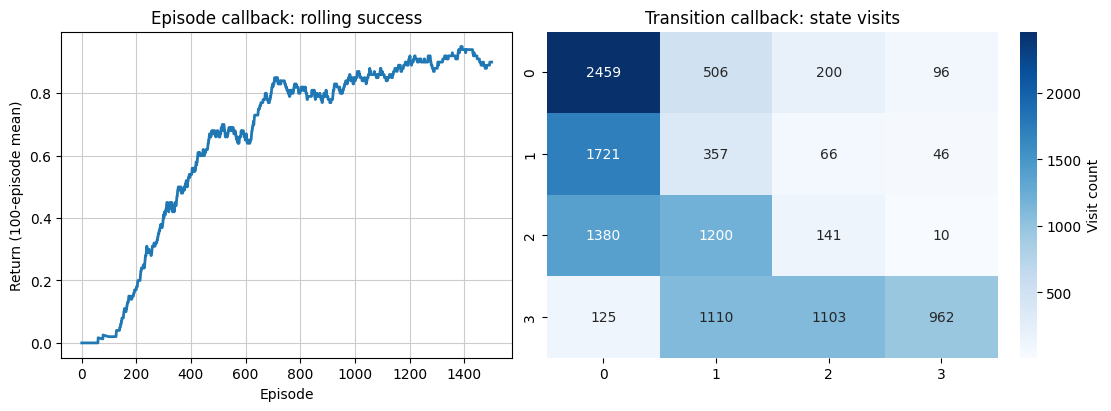

In [5]:
return_curve = prepare_learning_curve(episodes["return"], window=100)
visit_grid = prepare_value_grid(transition_diagnostics.state_visits, (4, 4), decimals=0)

fig, (return_ax, visit_ax) = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
plot_learning_curve(
    return_curve,
    ax=return_ax,
    title="Episode callback: rolling success",
    ylabel="Return (100-episode mean)",
    show_runs=False,
)
plot_value_heatmap(
    visit_grid,
    ax=visit_ax,
    title="Transition callback: state visits",
    value_label="Visit count",
    cmap="Blues",
)
plt.show()
plt.close(fig)

The learning curve makes the improving success frequency visible, while the heatmap exposes uneven coverage that a reward array cannot show. These are complementary diagnostics: one tracks training outcomes over time, and the other checks what experience produced them.